# Build volume-averaged flux from gsimple flux files 

(description added by Claude, edited by munjung@uchicago.edu)



This notebook reads **BNB gsimple** ROOT flux files with neutrino ray samples with per-entry weights

**Exposure:** `wgt` is left as in the file; after concatenating many ROOT files, spectra use
`TOTAL_POT = sum` of each file's meta POT so the estimate is **`sum(wgt) / TOTAL_POT`**

**Ray-traced FV volumes:** `FV_split` and `FV_split_truncY` use a track-length
volume average ($\sum w_i L_i / (V\,\mathrm{POT})$) (note this is different from the $z$-slab plane average of Gen 2 samples)

In [2]:
import os
import glob

import numpy as np
import matplotlib.pyplot as plt
import uproot
from tqdm import tqdm

try:
    plt.style.use("../numucc_1p0pi/presentation.mplstyle")
except OSError:
    pass


In [3]:
!ls

build_voxel_flux.py  gsimple.ipynb  raytrace_volume_defs.py
dk2nu.ipynb	     __pycache__


In [4]:
from raytrace_volume_defs import (
    FV_SPLIT_BOXES,
    FV_SPLIT_TRUNCY_BOXES,
    RAYTRACE_VOLUME_DEFS,
    RAYTRACE_VOLUME_LABEL,
    mask_xy_in_volume_at_z,
    plane_area_m2_at_z,
)

In [ ]:
FACE_Z_CM = 0.0
DOWNSTREAM_FACE_Z_CM = FACE_Z_CM + 500.0

face_windows = {
    r"AV ($\pm$200, $\pm$200)":          dict(x_range=(-200.0, 200.0), y_range=(-200.0, 200.0)),
    r"FV ($\pm$190, $\pm$190)":         dict(x_range=(-190.0, 190.0), y_range=(-190.0, 190.0)),
    r"FV 2 ($\pm$190, [-190,100])":    dict(x_range=(-190.0, 190.0), y_range=(-190.0, 100.0)),
}

SBND_VOLUME = dict(z_range_cm=(0.0, 500.0), y_range=(-200.0, 200.0), x_range=(-200.0, 200.0))

In [20]:
# stuff for plotters
Z_POSITIONS_CM = np.linspace(0.0, 500.0, 26)

E_BINS = np.linspace(0.0, 10.0, 81)
BIN_CENTERS = 0.5 * (E_BINS[:-1] + E_BINS[1:])


## Configuration and load paths


In [6]:
GSIMPLE_DIR = (
    "/cvmfs/sbnd.osgstorage.org/pnfs/fnal.gov/usr/sbnd/persistent/stash/"
    "fluxFiles/bnb/BooNEtoGSimple/configK-v1/july2023/neutrinoMode/"
)

# Number of files to process (set to None to process all)
N_FILES = 100

In [7]:
PDG_BY_FLAVOR = {
    "nue": 12,
    "nuebar": -12,
    "numu": 14,
    "numubar": -14,
}
FLAVORS = list(PDG_BY_FLAVOR.keys())
FLAVOR_LATEX = {
    "nue":     r"$\nu_e$",
    "nuebar":  r"$\bar{\nu}_e$",
    "numu":    r"$\nu_\mu$",
    "numubar": r"$\bar{\nu}_\mu$",
}

## Inspect Gsimple files


In [8]:
all_files = sorted(glob.glob(os.path.join(GSIMPLE_DIR, "*.root")))
print(f"Found {len(all_files)} files")

sample_file = all_files[0]
print("Sample file:", sample_file)

with uproot.open(sample_file) as f:
    print("\nKeys:", f.keys())

    print("\n--- flux tree branches ---")
    tree = f["flux"]
    for k in tree.keys():
        print(" ", k)

    print("\n--- meta tree branches ---")
    meta_key = next((k for k in f.keys() if "meta" in k.lower()), None)
    if meta_key:
        meta = f[meta_key]
        for k in meta.keys():
            print(" ", k)
        pot_key = next((k for k in meta.keys() if "proton" in k.lower()), None)
        if pot_key:
            val = meta[pot_key].array(library="np")[0]
            print(f"\n  First entry of '{pot_key}': {val:.6g}")
    else:
        print("  (no meta tree found)")


Found 5000 files
Sample file: /cvmfs/sbnd.osgstorage.org/pnfs/fnal.gov/usr/sbnd/persistent/stash/fluxFiles/bnb/BooNEtoGSimple/configK-v1/july2023/neutrinoMode/gsimple_april07_baseline_0000_redecay_wkaonwgh.root

Keys: ['flux;1', 'meta;1']

--- flux tree branches ---
  entry
  entry/wgt
  entry/vtxx
  entry/vtxy
  entry/vtxz
  entry/vtxt
  entry/dist
  entry/px
  entry/py
  entry/pz
  entry/E
  entry/pdg
  entry/metakey
  numi
  numi/tpx
  numi/tpy
  numi/tpz
  numi/vx
  numi/vy
  numi/vz
  numi/pdpx
  numi/pdpy
  numi/pdpz
  numi/pppx
  numi/pppy
  numi/pppz
  numi/ndecay
  numi/ptype
  numi/ppmedium
  numi/tptype
  numi/run
  numi/evtno
  numi/entryno
  aux
  aux/auxint
  aux/auxdbl

--- meta tree branches ---
  meta
  meta/TObject
  meta/TObject/fUniqueID
  meta/TObject/fBits
  meta/pdglist
  meta/maxEnergy
  meta/minWgt
  meta/maxWgt
  meta/protons
  meta/windowBase[3]
  meta/windowDir1[3]
  meta/windowDir2[3]
  meta/auxintname
  meta/auxdblname
  meta/infiles
  meta/seed
  meta/met

## Load flux


In [9]:
def _get_pot(f):
    meta_key = next((k for k in f.keys() if "meta" in k.lower()), None)
    if meta_key is None:
        raise RuntimeError("No meta tree found; cannot read POT.")
    meta = f[meta_key]
    pot_key = next((k for k in meta.keys() if "proton" in k.lower()), None)
    if pot_key is None:
        raise RuntimeError(f"No 'protons' branch found in meta tree; keys = {list(meta.keys())}")
    return float(meta[pot_key].array(library="np").sum())


def load_gsimple(filename):
    # Coordinates are converted to cm; momenta and energy stay in GeV.
    with uproot.open(filename) as f:
        pot = _get_pot(f)
        tree = f["flux"]
        keys = tree.keys()
        if "entry/pdg" in keys:
            prefix = "entry/"
        elif "pdg" in keys:
            prefix = ""
        else:
            raise RuntimeError(f"Cannot find 'pdg' branch in {filename}; keys = {list(keys)}")

        branches = [
            prefix + "pdg",
            prefix + "wgt",
            prefix + "vtxx",
            prefix + "vtxy",
            prefix + "vtxz",
            prefix + "px",
            prefix + "py",
            prefix + "pz",
            prefix + "E",
        ]
        arr = tree.arrays(branches, library="np")

    pdg = arr[prefix + "pdg"]
    return {
        "pot": pot,
        "pdg": pdg,
        "wgt": arr[prefix + "wgt"],
        "vtxx": arr[prefix + "vtxx"] * 100.0,
        "vtxy": arr[prefix + "vtxy"] * 100.0,
        "vtxz": arr[prefix + "vtxz"] * 100.0,
        "px": arr[prefix + "px"],
        "py": arr[prefix + "py"],
        "pz": arr[prefix + "pz"],
        "E": arr[prefix + "E"],
    }


In [10]:
files_to_process = all_files[:N_FILES] if N_FILES is not None else all_files
print(f"Processing {len(files_to_process)} file(s)…")

chunks = []
for fpath in tqdm(files_to_process):
    try:
        chunks.append(load_gsimple(fpath))
    except Exception as e:
        print(f"  [skip] {os.path.basename(fpath)}: {e}")

array_keys = [k for k in chunks[0].keys() if k != "pot"]
data = {k: np.concatenate([c[k] for c in chunks]) for k in array_keys}
TOTAL_POT = float(sum(c["pot"] for c in chunks))

print(f"Total entries : {len(data['E']):,}")
print(f"Total simulated POT (sum over files): {TOTAL_POT:.4g}")

p_mag = np.sqrt(data["px"]**2 + data["py"]**2 + data["pz"]**2)
data["dx"] = data["px"] / p_mag
data["dy"] = data["py"] / p_mag
data["dz"] = data["pz"] / p_mag


Processing 100 file(s)…


  0%|          | 0/100 [00:00<?, ?it/s]

100%|██████████| 100/100 [00:17<00:00,  5.80it/s]


Total entries : 15,105,787
Total simulated POT (sum over files): 1e+09


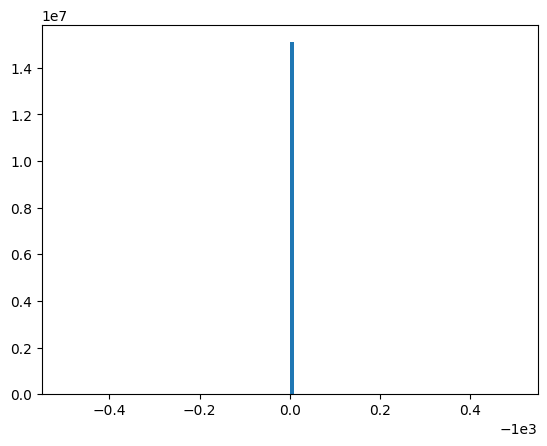

In [11]:
# check that neutrino "vertex" is -10m upstream of detector face
plt.hist(data["vtxz"], bins=100)
plt.show();

## Plot helpers

Weighted histograms give neutrino flux in each energy bin per **total stacked exposure**.
Dividing by the flux window area (m$^2$) turns that into an average **flux density**
$\phi$ in $\mathrm{m}^{-2}\,\mathrm{POT}^{-1}$ per bin

In [17]:
def window_area_m2(x_range, y_range):
    return (x_range[1] - x_range[0]) * (y_range[1] - y_range[0]) * (0.01**2)


def project_to_z(data, z_target_cm):
    # Project ray to a z position
    slope_x = data["px"] / data["pz"]
    slope_y = data["py"] / data["pz"]
    dz = z_target_cm - data["vtxz"]
    x_cm = data["vtxx"] + slope_x * dz
    y_cm = data["vtxy"] + slope_y * dz
    return x_cm, y_cm


def mask_xy(x_cm, y_cm, x_range, y_range):
    return (
        (x_cm >= x_range[0]) & (x_cm < x_range[1])
        & (y_cm >= y_range[0]) & (y_cm < y_range[1])
    )


def spectrum_at_plane(data, flavor, z_cm, x_range, y_range):
    x_cm, y_cm = project_to_z(data, z_cm)
    pdg = PDG_BY_FLAVOR[flavor]
    m = (data["pdg"] == pdg) & mask_xy(x_cm, y_cm, x_range, y_range)
    area = window_area_m2(x_range, y_range)
    h, _ = np.histogram(data["E"][m], bins=E_BINS, weights=data["wgt"][m])
    return h / (area * TOTAL_POT)


def spectrum_at_plane_volume(data, flavor, z_cm, boxes):
    x_cm, y_cm = project_to_z(data, z_cm)
    pdg = PDG_BY_FLAVOR[flavor]
    m = (data["pdg"] == pdg) & mask_xy_in_volume_at_z(x_cm, y_cm, z_cm, boxes)
    area = plane_area_m2_at_z(z_cm, boxes)
    if area <= 0.0:
        return np.zeros(len(BIN_CENTERS))
    h, _ = np.histogram(data["E"][m], bins=E_BINS, weights=data["wgt"][m])
    return h / (area * TOTAL_POT)


def integrated_flux(spectrum):
    return float(np.sum(spectrum))


# def volume_mean_spectrum(data, flavor, z_cm_values, x_range, y_range):
#     # Mean of plane spectra over listed z slab centers (fixed rectangular window).
#     stacks = [spectrum_at_plane(data, flavor, z, x_range, y_range) for z in z_cm_values]
#     return np.mean(np.stack(stacks, axis=0), axis=0)


# def volume_mean_spectrum_boxes(data, flavor, z_cm_values, boxes):
#     # Mean of plane spectra over z; geometry matches raytrace_volume_defs at each z.
#     stacks = [spectrum_at_plane_volume(data, flavor, z, boxes) for z in z_cm_values]
#     return np.mean(np.stack(stacks, axis=0), axis=0)


def _slab_t(v, d, lo, hi):
    # with np.errstate(divide="ignore", invalid="ignore"):
    t1 = (lo - v) / d
    t2 = (hi - v) / d
    t_near = np.minimum(t1, t2)
    t_far = np.maximum(t1, t2)
    parallel = d == 0
    if np.any(parallel):
        inside = (v >= lo) & (v <= hi)
        t_near = np.where(parallel, np.where(inside, -np.inf, np.inf), t_near)
        t_far = np.where(parallel, np.where(inside, np.inf, -np.inf), t_far)
    return t_near, t_far


def path_length_box(vx, vy, vz, dx, dy, dz, box):
    tx_n, tx_f = _slab_t(vx, dx, *box["x_range"])
    ty_n, ty_f = _slab_t(vy, dy, *box["y_range"])
    tz_n, tz_f = _slab_t(vz, dz, *box["z_range"])
    t_enter = np.maximum.reduce([tx_n, ty_n, tz_n, np.zeros_like(vx)])
    t_exit = np.minimum.reduce([tx_f, ty_f, tz_f])
    return np.maximum(0.0, t_exit - t_enter)


def path_length_volume(data, boxes):
    L = np.zeros_like(data["vtxx"])
    for box in boxes:
        L += path_length_box(
            data["vtxx"], data["vtxy"], data["vtxz"],
            data["dx"], data["dy"], data["dz"], box,
        )
    return L


def volume_cm3(boxes):
    v = 0.0
    for b in boxes:
        v += ((b["x_range"][1] - b["x_range"][0]) * (b["y_range"][1] - b["y_range"][0]) * (b["z_range"][1] - b["z_range"][0]))
    return v


def raytraced_spectrum(data, flavor, boxes, path_lengths=None):
    if path_lengths is None:
        path_lengths = path_length_volume(data, boxes)
    V = volume_cm3(boxes)
    pdg = PDG_BY_FLAVOR[flavor]
    m = (data["pdg"] == pdg) & (path_lengths > 0)
    h, _ = np.histogram(
        data["E"][m], bins=E_BINS, weights=data["wgt"][m] * path_lengths[m],
    )
    return h * 1.0e4 / (V * TOTAL_POT)


## Ray-traced volume-averaged flux 

Track-length estimator: 

$\phi(E) = \sum_i w_i L_i / (V\,\mathrm{POT})$  ($\mathrm{m}^{-2}\,\mathrm{POT}^{-1}$ per 50 MeV bin.)

- $L_i$: path length [cm] through the 3D volume
- $V$ the union volume in cm$^3$. Units of
the spectrum: 

1. **`FV_split` (old) **: $10 < |x| < 190$, $|y| < 190$, $10 < z < 450$ cm (two anode slabs).
2. **`FV_split_truncY` (Gen 1 DENT mitigated FV)**: same $10 < |x| < 190$ slabs; $|y| < 190$ for $10 < z < 250$, $-190 < y < 100$ for $250 < z < 450$ cm.


In [18]:
SBND_VOLUME["z_range_cm"]

(0.0, 500.0)

L_mean = 416.7 cm
L_mean = 374.8 cm


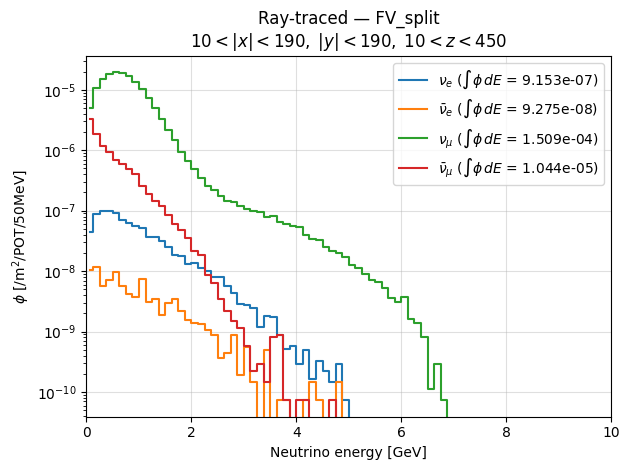

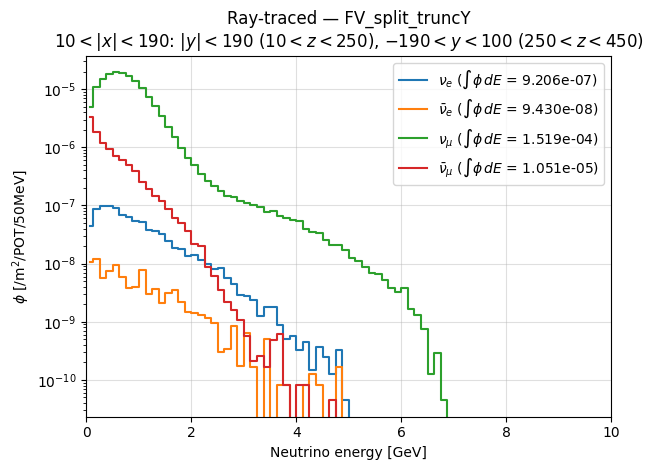

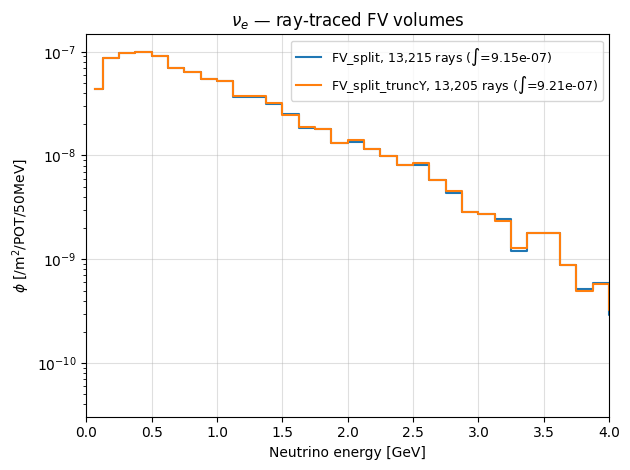

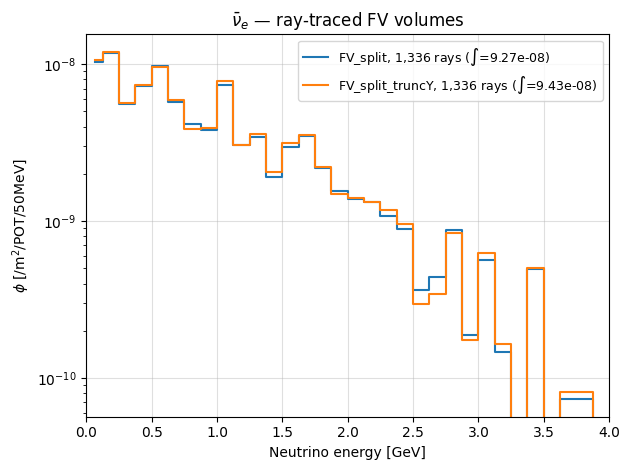

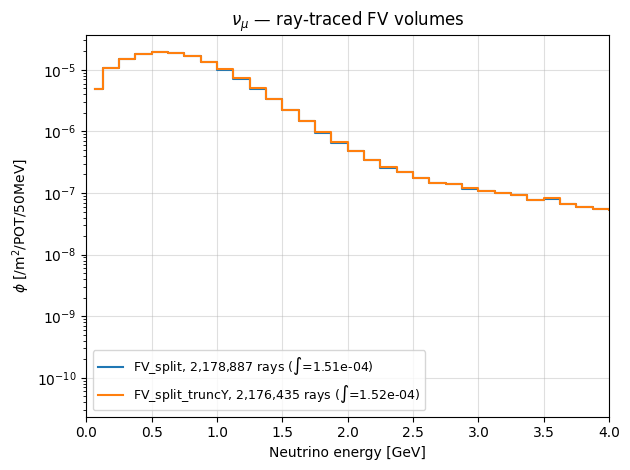

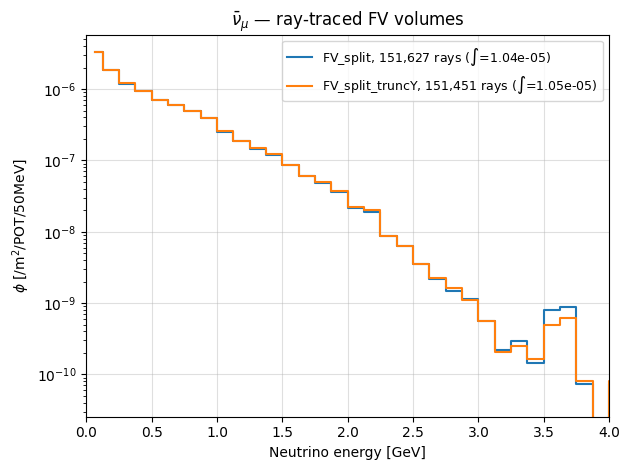

In [22]:
raytrace_spectra = {vname: {} for vname, _ in RAYTRACE_VOLUME_DEFS}
path_lengths = {}
for vname, boxes in RAYTRACE_VOLUME_DEFS:
    L = path_length_volume(data, boxes)
    path_lengths[vname] = L
    n_hit = int(np.sum(L > 0))
    L_mean = float(np.mean(L[L > 0])) if n_hit else 0.0
    print(f"L_mean = {L_mean:.1f} cm")
    for flav in FLAVORS:
        raytrace_spectra[vname][flav] = raytraced_spectrum(
            data, flav, boxes, path_lengths=L
        )

for vname, _ in RAYTRACE_VOLUME_DEFS:
    fig, ax = plt.subplots()
    for flav in FLAVORS:
        spec = raytrace_spectra[vname][flav]
        integ = integrated_flux(spec)
        ax.step(
            BIN_CENTERS, spec, where="mid",
            label=rf"{FLAVOR_LATEX[flav]} ($\int\phi\,dE$ = {integ:.3e})",
        )
    ax.set_xlim(0, E_BINS[-1])
    ax.set_xlabel("Neutrino energy [GeV]")
    ax.set_ylabel(r"$\phi$ [/m$^2$/POT/50MeV]")
    ax.set_yscale("log")
    ax.grid(True, alpha=0.4)
    ax.legend(fontsize=10)
    ax.set_title(f"Ray-traced — {vname}\n{RAYTRACE_VOLUME_LABEL[vname]}")
    plt.tight_layout()
    plt.show()

for flav in FLAVORS:
    fig, ax = plt.subplots()
    for vname, _ in RAYTRACE_VOLUME_DEFS:
        spec = raytrace_spectra[vname][flav]
        n_rays = int(np.sum(path_lengths[vname][data["pdg"] == PDG_BY_FLAVOR[flav]] > 0))
        integ = integrated_flux(spec)
        ax.step(
            BIN_CENTERS, spec, where="mid",
            label=rf"{vname}, {n_rays:,} rays ($\int$={integ:.2e})",
        )
    ax.set_xlim(0, 4)
    ax.set_xlabel("Neutrino energy [GeV]")
    ax.set_ylabel(r"$\phi$ [/m$^2$/POT/50MeV]")
    ax.set_yscale("log")
    ax.grid(True, alpha=0.4)
    ax.legend(fontsize=9)
    ax.set_title(f"{FLAVOR_LATEX[flav]} — ray-traced FV volumes")
    plt.tight_layout()
    plt.show()

# # Slab (z-plane mean) spectra with the same FV geometry as raytrace
# z_lo_fv, z_hi_fv = SLAB_Z_RANGE_FV_CM
# z_fv_slabs = np.linspace(z_lo_fv, z_hi_fv, 51)
# slab_volume_spectra = {vname: {} for vname, _ in RAYTRACE_VOLUME_DEFS}
# for vname, boxes in RAYTRACE_VOLUME_DEFS:
#     for flav in FLAVORS:
#         slab_volume_spectra[vname][flav] = volume_mean_spectrum_boxes(
#             data, flav, z_fv_slabs, boxes
#         )


## Flux through the flux window at different `z`

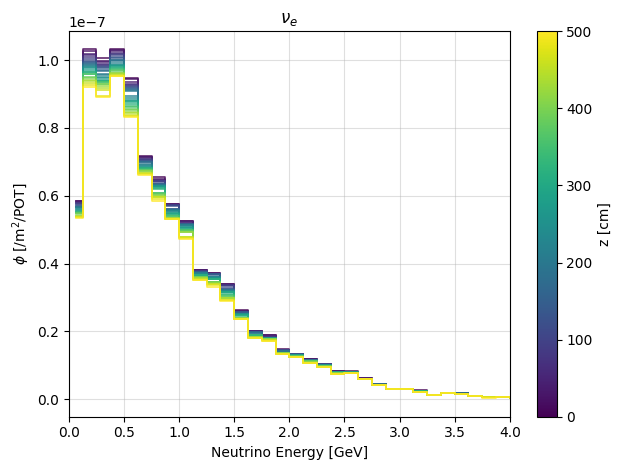

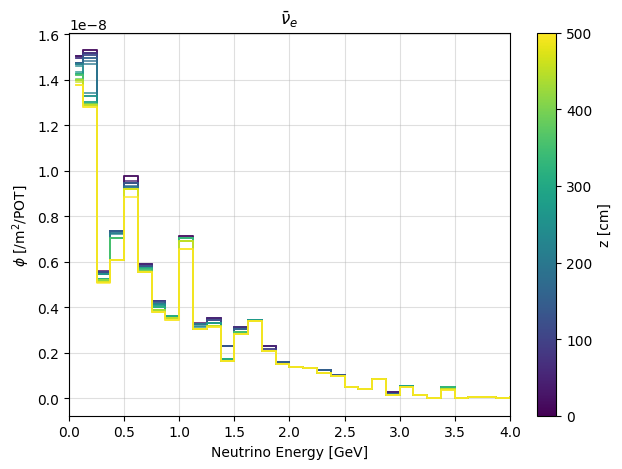

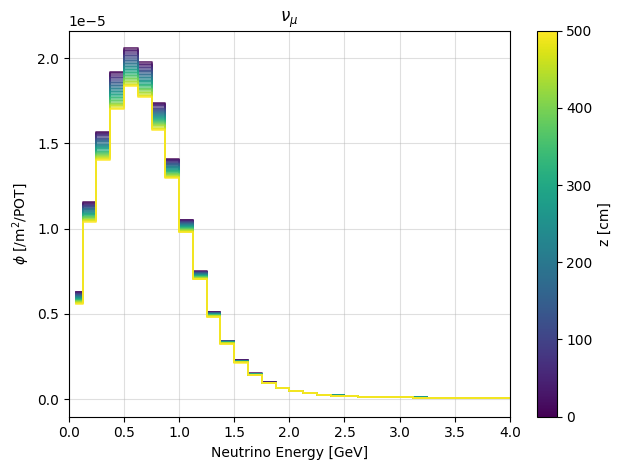

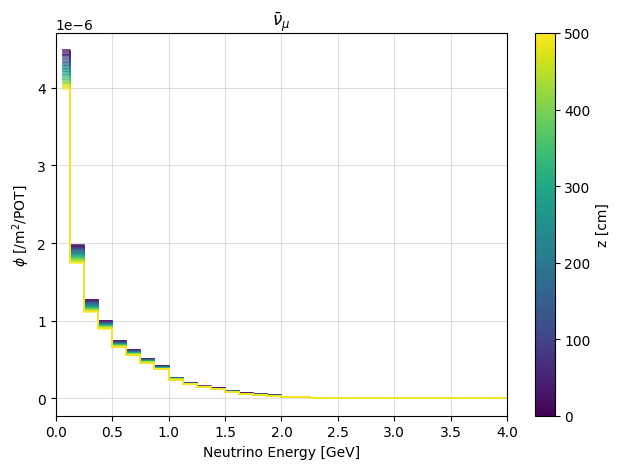

In [24]:
flux_window = dict(x_range=(-190.0, 190.0), y_range=(-190.0, 190.0))

z_slabs = list(Z_POSITIONS_CM)
z_slab_spectra = {flav: np.zeros((len(z_slabs), len(BIN_CENTERS))) for flav in FLAVORS}
z_slab_integ = {flav: np.zeros(len(z_slabs)) for flav in FLAVORS}

for iz, z in enumerate(z_slabs):
    for flav in FLAVORS:
        spec = spectrum_at_plane(data, flav, z, **flux_window)
        z_slab_spectra[flav][iz] = spec
        z_slab_integ[flav][iz] = integrated_flux(spec)

cmap = plt.cm.viridis
norm = plt.Normalize(vmin=z_slabs[0], vmax=z_slabs[-1])
for flav in FLAVORS:
    fig, ax = plt.subplots()
    for iz, z in enumerate(z_slabs):
        ax.step(
            BIN_CENTERS,
            z_slab_spectra[flav][iz],
            where="mid",
            color=cmap(norm(z)),
            alpha=0.85,
            linewidth=1.2,
            label=f"z={z:.0f} cm",
        )
    ax.set_xlim(0, 4)
    ax.set_xlabel("Neutrino Energy [GeV]")
    ax.set_ylabel(r"$\phi$ [/m$^2$/POT]")
    ax.set_title(f"{FLAVOR_LATEX[flav]}")
    ax.grid(True, alpha=0.4)
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    fig.colorbar(sm, ax=ax, label="z [cm]")
    plt.tight_layout()
    plt.show()


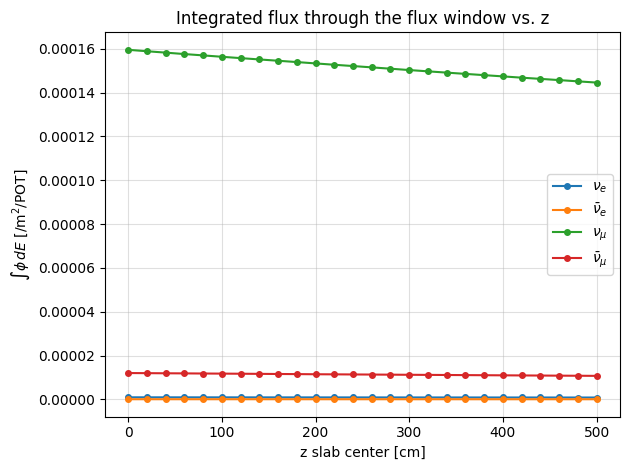

In [25]:
fig, ax = plt.subplots()
for flav in FLAVORS:
    ax.plot(
        z_slabs,
        z_slab_integ[flav],
        marker="o",
        markersize=4,
        label=FLAVOR_LATEX[flav],
    )
ax.set_xlabel("z slab center [cm]")
ax.set_ylabel(r"$\int \phi\,dE$ [/m$^2$/POT]")
ax.set_title("Integrated flux through the flux window vs. z")
ax.legend()
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()


## Flux at the detector face with different `(x, y)` windows

In [27]:
face_windows

{'AV ($\\pm$200, $\\pm$200)': {'x_range': (-200.0, 200.0),
  'y_range': (-200.0, 200.0)},
 'FV ($\\pm$190, $\\pm$190)': {'x_range': (-190.0, 190.0),
  'y_range': (-190.0, 190.0)},
 'FV 2 ($\\pm$190, [-190,100])': {'x_range': (-190.0, 190.0),
  'y_range': (-190.0, 100.0)}}

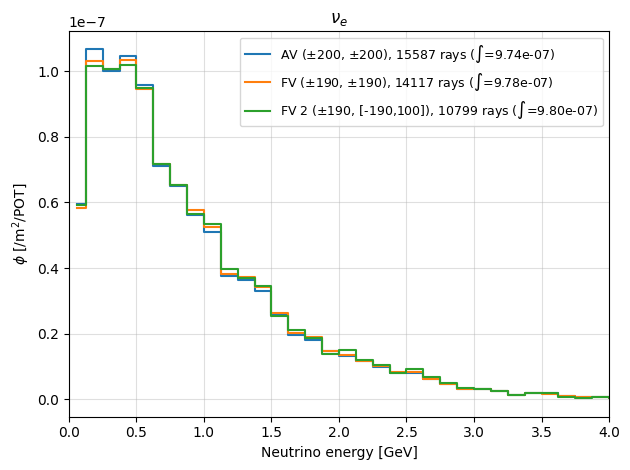

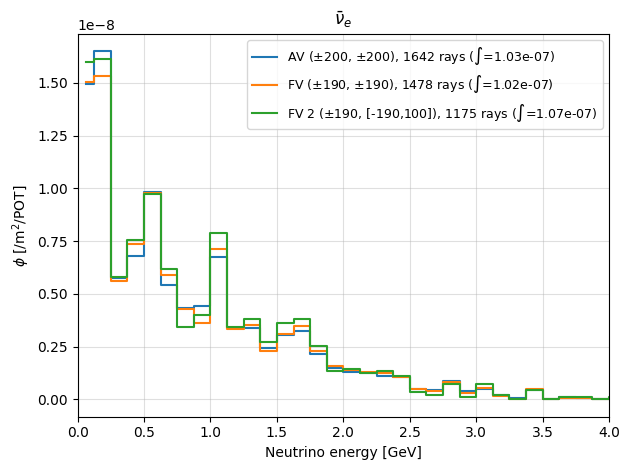

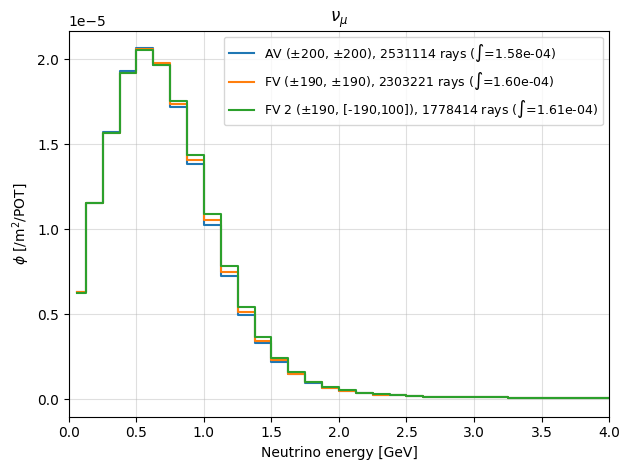

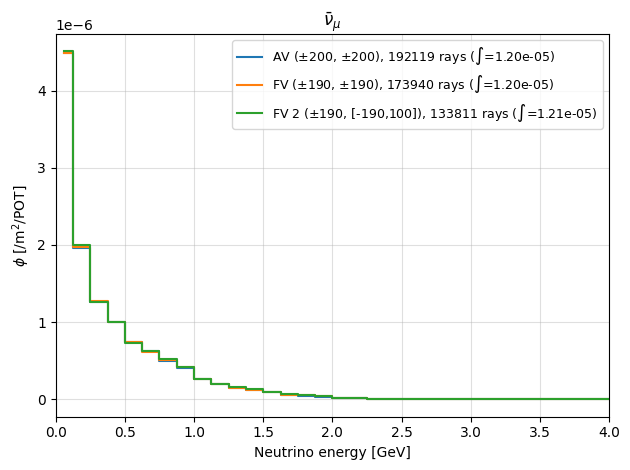

In [28]:
z_face_cm = FACE_Z_CM

face_spectra = {flav: {} for flav in FLAVORS}
for label, win in face_windows.items():
    for flav in FLAVORS:
        spec = spectrum_at_plane(data, flav, z_face_cm, **win)
        x_cm, y_cm = project_to_z(data, z_face_cm)
        m = (data["pdg"] == PDG_BY_FLAVOR[flav]) & mask_xy(x_cm, y_cm, **win)
        n_rays = int(np.sum(m))
        face_spectra[flav][label] = (spec, n_rays)

for flav in FLAVORS:
    fig, ax = plt.subplots()
    for label, (spec, n_rays) in face_spectra[flav].items():
        integ = integrated_flux(spec)
        ax.step(
            BIN_CENTERS,
            spec,
            where="mid",
            label=rf"{label}, {n_rays} rays ($\int$={integ:.2e})",
        )
    ax.set_xlim(0, 4)
    ax.set_xlabel("Neutrino energy [GeV]")
    ax.set_ylabel(r"$\phi$ [/m$^2$/POT]")
    ax.set_title(f"{FLAVOR_LATEX[flav]}")
    ax.grid(True, alpha=0.4)
    ax.legend(fontsize=9, loc="upper right")
    plt.tight_layout()
    plt.show()
